## Question 1: Find SST and Chlorophyll datasets over Gulf of Maine.  

In [ ]:
from erddapy.multiple_server_search import search_servers


df = search_servers(
    query="SST",
    parallel=True,
    protocol="griddap",
)

In [ ]:
df

https://mathewbiddle.github.io/search-erddaps/#search=SST+Multi-scale+Ultra-high+Resolution

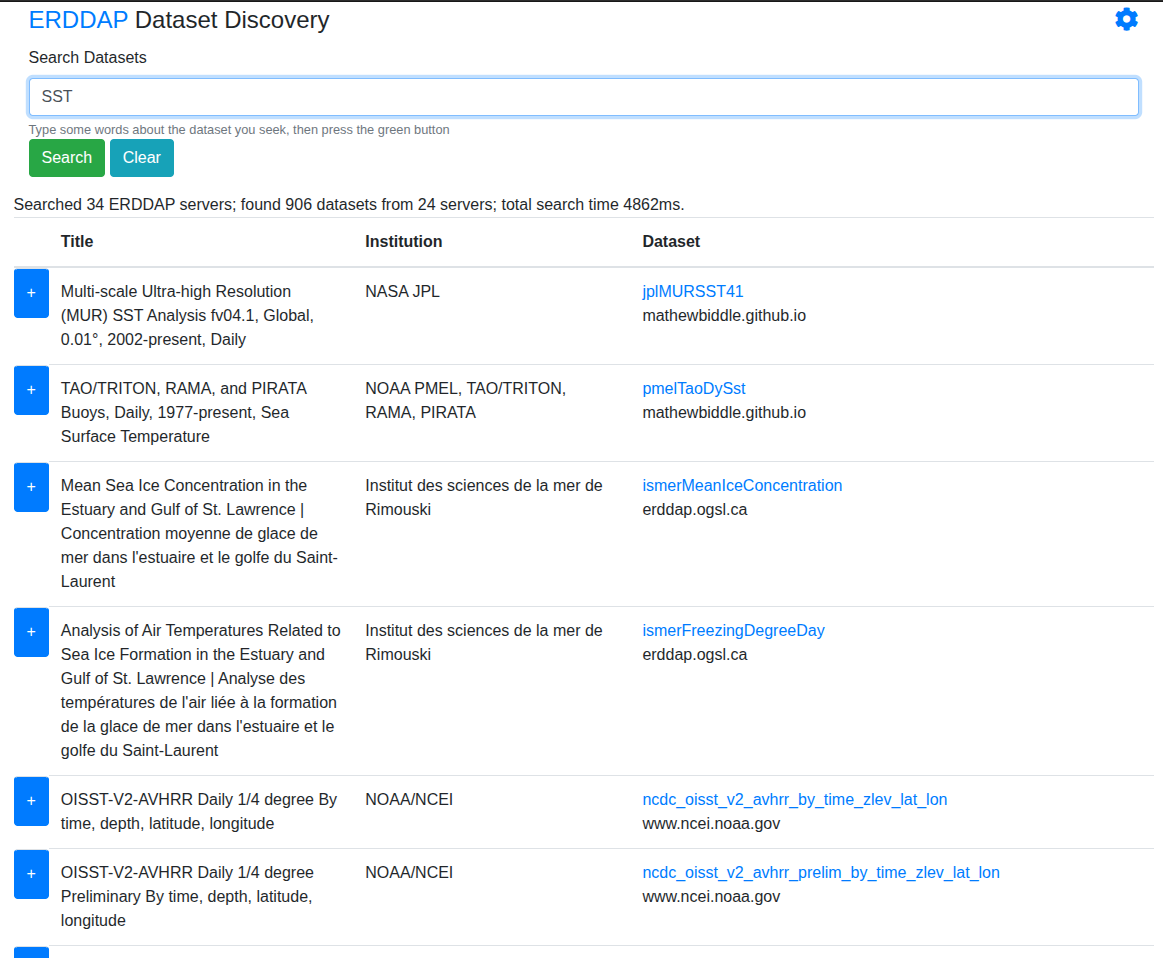

In [ ]:
mask = []
for title in df["Title"]:
    if "Multi-scale Ultra-high Resolution" in title:
        mask.append(True)
    else:
        mask.append(False)

In [ ]:
df.loc[mask]

In [ ]:
set(df.loc[mask]["Server url"])

In [ ]:
from erddapy import ERDDAP


server = "https://coastwatch.pfeg.noaa.gov/erddap"
# server = "https://oceanview.pfeg.noaa.gov/erddap/"
# server = "https://erddap.emodnet.eu/erddap/"

xmin, xmax, ymin, ymax = -71.25, -64.36, 40.90, 44.83
start = "2026-05-23"
    
e = ERDDAP(
    server=server,
    protocol="griddap",
)
e.dataset_id = "jplMURSST41"
e.variables  = ["analysed_sst"]

e.constraints["time>="] = start
e.constraints["latitude>="] = ymin
e.constraints["latitude<="] = ymax
e.constraints["longitude>="] = xmin
e.constraints["longitude<="] = xmax

sst = e.to_xarray()

In [ ]:
cs = sst["analysed_sst"].plot()

In [ ]:
from erddapy import ERDDAP


xmin, xmax, ymin, ymax = -71.25, -64.36, 40.90, 44.83
start = "2026-05-23"

e = ERDDAP(
    server="https://coastwatch.pfeg.noaa.gov/erddap",
    protocol="griddap",
)

e.dataset_id = "nesdisVHNnoaaSNPPnoaa20NRTchlaGapfilledDaily"
e.variables  = ["chlor_a"]

e.constraints["time>="] = start
e.constraints["latitude>="] = ymin
e.constraints["latitude<="] = ymax
e.constraints["longitude>="] = xmin
e.constraints["longitude<="] = xmax

chla = e.to_xarray()

In [ ]:
import numpy as np


logc = np.log10(chla["chlor_a"])
cs = logc.plot()

## Question 2: Past 7 days of glider data for the West Coast.

In [ ]:
import datetime as dt
from gliderpy import GliderDataFetcher


end = dt.datetime(2026, 5, 23, tzinfo=dt.timezone.utc)
start = end - dt.timedelta(days=7)
xmin, xmax, ymin, ymax = -130.55, -117.23, 32.63, 48.95

glider_grab = GliderDataFetcher()

df = glider_grab.query(
    min_lat=ymin,
    max_lat=ymax,
    min_lon=xmin,
    max_lon=xmax,
    min_time=start,
    max_time=end,
)

df

In [ ]:
from gliderpy.fetchers import GliderDataFetcher


glider_grab = GliderDataFetcher()
glider_grab.dataset_ids = df["Dataset ID"].tolist()

dfs = glider_grab.to_pandas()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

for dataset_id, glider in dfs.items():
    dfs[dataset_id].plot_track(ax=ax)

dx = dy = 5
ax.set_extent(
    [
        xmin-dx,
        xmax+dx,
        ymin-dy,
        ymax+dy,
    ]
)

gl = ax.gridlines(draw_labels=True)
gl.left_labels = gl.top_labels = False